In [10]:
import pandas as pd

def read_csv_to_dataframe(file_path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return pd.DataFrame()

In [11]:
Rosedata_df = read_csv_to_dataframe("Event_core_v4.csv")

In [12]:
print(Rosedata_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_date                    29 non-null     object 
 1   event_id                      29 non-null     object 
 2   parent_event_id               46 non-null     object 
 3   type                          46 non-null     object 
 4   location_id                   46 non-null     object 
 5   decimal_latitud               29 non-null     float64
 6   decimal_longitude             29 non-null     float64
 7   depth_m                       46 non-null     int64  
 8   habitat                       46 non-null     object 
 9   conteo_ind                    46 non-null     int64  
 10  temperat_grad_c               46 non-null     float64
 11  total_organic_matter_percent  46 non-null     float64
 12  proport_silt_clay_percent     46 non-null     int64  
 13  prop_si

Kruskal-Wallis:

In [13]:
from scipy.stats import kruskal

def kruskal_wallis_test(*groups, alpha=0.05):
    """
    Performs the Kruskal-Wallis H-test for independent samples.
    Accepts multiple groups as arguments.
    Prints the H statistic, p-value, and interpretation.
    """
    result = kruskal(*groups)
    
    print(f"H statistic = {result.statistic}")
    print(f"p-value = {result.pvalue}")
    
    if result.pvalue < alpha:
        print("The difference between groups is statistically significant.")
    else:
        print("No statistically significant difference between groups.")


In [14]:
%pip install scikit-posthocs
import scikit_posthocs as sp

def dunn_posthoc(data, group_col, value_col, p_adjust='bonferroni'):
    """
    Runs Dunn's post-hoc test after Kruskal-Wallis.
    """
    result = sp.posthoc_dunn(data, val_col=value_col, group_col=group_col, p_adjust=p_adjust)
    print(result)
    return result

Note: you may need to restart the kernel to use updated packages.


Nota: Para realizar este ejercicio añadí GM (Gulfo de México) con los mismos valores de GG. En este caso GM es hipotético, se repiten los datos de GG.

* Para la Temperatura:

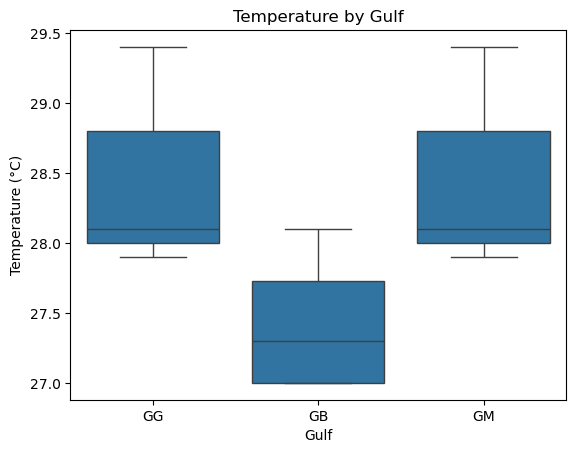

In [27]:
# Plot temperature values for each gulf using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='parent_event_id', y='temperat_grad_c', data=Rosedata_df)
plt.xlabel('Gulf')
plt.ylabel('Temperature (°C)')
plt.title('Temperature by Gulf')
plt.show()

In [28]:
# Select the data for each gulf
temp_GG = Rosedata_df[Rosedata_df['parent_event_id'] == 'GG']['temperat_grad_c']
temp_GB = Rosedata_df[Rosedata_df['parent_event_id'] == 'GB']['temperat_grad_c']
temp_GM = Rosedata_df[Rosedata_df['parent_event_id'] == 'GM']['temperat_grad_c']

In [29]:
# Perform the Kruskal-Wallis test para temterature
kruskal_wallis_test(temp_GG, temp_GB, temp_GM)

H statistic = 15.598434939638164
p-value = 0.00041005573445106663
The difference between groups is statistically significant.


In [30]:
# Puedo ver entre quienes hay diferencias:
dunn_posthoc(Rosedata_df, 'parent_event_id', 'temperat_grad_c', p_adjust='bonferroni')

          GB        GG        GM
GB  1.000000  0.001308  0.001308
GG  0.001308  1.000000  1.000000
GM  0.001308  1.000000  1.000000


,GB,GG,GM
GB,1.000000,0.001308,0.001308
GG,0.001308,1.000000,1.000000
GM,0.001308,1.000000,1.000000


* Para la Materia Orgánica Total:

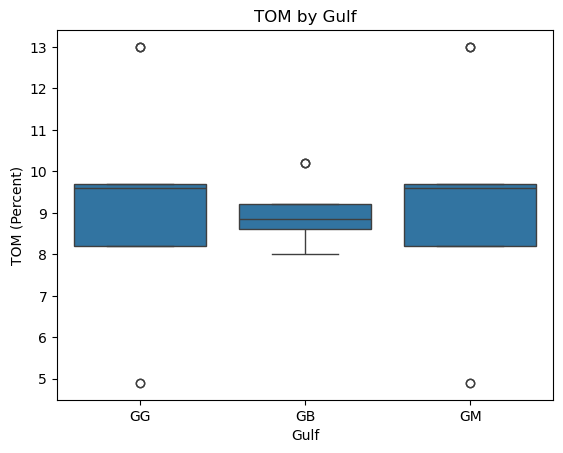

In [31]:
# Plot TOM values for each gulf using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='parent_event_id', y='total_organic_matter_percent', data=Rosedata_df)
plt.xlabel('Gulf')
plt.ylabel('TOM (Percent)')
plt.title('TOM by Gulf')
plt.show()

In [32]:
# Select the data for each gulf
tom_GG = Rosedata_df[Rosedata_df['parent_event_id'] == 'GG']['total_organic_matter_percent']
tom_GB = Rosedata_df[Rosedata_df['parent_event_id'] == 'GB']['total_organic_matter_percent']
tom_GM = Rosedata_df[Rosedata_df['parent_event_id'] == 'GM']['total_organic_matter_percent']

In [33]:
# Perform the Kruskal-Wallis test para TOM
kruskal_wallis_test(tom_GG, tom_GB, tom_GM)

H statistic = 0.09110714993065945
p-value = 0.9554684120136533
No statistically significant difference between groups.


In [34]:
dunn_posthoc(Rosedata_df, 'parent_event_id', 'total_organic_matter_percent', p_adjust='bonferroni')

     GB   GG   GM
GB  1.0  1.0  1.0
GG  1.0  1.0  1.0
GM  1.0  1.0  1.0


,GB,GG,GM
GB,1.0,1.0,1.0
GG,1.0,1.0,1.0
GM,1.0,1.0,1.0
